# General code

In [10]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt
from typing import Union
import pandas as pd

def _butter_filter(ts, fs, hp_cutoff=None, lp_cutoff=None, order=4):
    """High/low/band pass filter, same as before."""
    nyq = 0.5 * fs
    if hp_cutoff is None and lp_cutoff is None:
        return ts

    if hp_cutoff and lp_cutoff:
        btype = 'band'
        freqs = [hp_cutoff/nyq, lp_cutoff/nyq]
    elif hp_cutoff:
        btype = 'high'; freqs = hp_cutoff/nyq
    else:
        btype = 'low';  freqs = lp_cutoff/nyq

    b, a = butter(order, freqs, btype=btype)
    return filtfilt(b, a, ts)

# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(data: Union[xr.DataArray, np.ndarray],
                      fs: float,
                      poly_order: int = 1,
                      hp_cutoff: float = None,
                      lp_cutoff: float = None,
                      filter_order: int = 4) -> np.ndarray:
    """
    Globally filter and detrend the data, then return as numpy array.
    Handles both xarray DataArrays and 1D numpy arrays.
    """
    # Handle 1D numpy array input
    if isinstance(data, np.ndarray):
        if data.ndim != 1:
            raise ValueError("Numpy array input must be 1D")
        
        ts = data.astype(float)
        N = len(ts)
        tidx = np.arange(N)
        
        # Filter
        tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
        
        # Detrend
        coeffs = np.polyfit(tidx, tsf, poly_order)
        return tsf - np.polyval(coeffs, tidx)
    
    # Handle xarray DataArray (original code)
    axes = data.coords['axis'].values
    chans = data.coords['channel'].values
    full = data.copy(deep=True).astype(float)
    N = full.sizes['time']
    tidx = np.arange(N)
    
    for ax in axes:
        for ch in chans:
            ts = full.sel(axis=ax, channel=ch).values
            tsf = _butter_filter(ts, fs, hp_cutoff, lp_cutoff, filter_order)
            coeffs = np.polyfit(tidx, tsf, poly_order)
            full.loc[dict(axis=ax, channel=ch)] = tsf - np.polyval(coeffs, tidx)
    
    return full.values

def get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=None):
    """
    Get the first foot strike after start_time and last foot strike before end_time.
    
    Parameters:
    -----------
    events_path : Path
        Path to the events file (.nc or .csv)
    foot : str
        'Right' or 'Left' foot
    start_time : float
        Time in seconds to find first foot strike after (default: 20.0)
    end_time : float
        Time in seconds to find last foot strike before (default: 120.0)
    
    Returns:
    --------
    dict : Dictionary with 'first_strike' and 'last_strike' times in seconds
           Returns None for either if not found
    """
    # Load events based on file type
    if events_path.suffix == '.csv':
        df_events = pd.read_csv(events_path)
    elif events_path.suffix == '.nc':
        events_ds = xr.open_dataset(events_path)
        events_da = events_ds["events"] if "events" in events_ds else events_ds
        df_events = events_da.to_dataframe().reset_index()
    else:
        raise ValueError(f"Unsupported file type: {events_path.suffix}")
    
    # Filter for foot strikes on the specified foot within the time range
    foot_strikes = df_events[
        (df_events['label'] == 'Foot Strike') & 
        (df_events['context'] == foot) &
        (df_events['time'] >= start_time) &
        (df_events['time'] <= end_time)
    ]
    
    # Get first and last strike times
    first_strike = foot_strikes['time'].min() if len(foot_strikes) > 0 else None
    last_strike = foot_strikes['time'].max() if len(foot_strikes) > 0 else None
    
    return {
        'first_strike': first_strike,
        'last_strike': last_strike
    }


def get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=None):
    """
    Calculate the mean duration between consecutive foot strikes for a specific foot.
    
    Parameters:
    -----------
    events_path : Path
        Path to the events file (.nc or .csv)
    foot : str
        'Right' or 'Left' foot
    start_time : float
        Start time in seconds
    end_time : float
        End time in seconds
    
    Returns:
    --------
    dict : Dictionary with mean_duration, std_duration, num_strides, and all durations
    """
    # Load events based on file type
    if events_path.suffix == '.csv':
        df_events = pd.read_csv(events_path)
    elif events_path.suffix == '.nc':
        events_ds = xr.open_dataset(events_path)
        events_da = events_ds["events"] if "events" in events_ds else events_ds
        df_events = events_da.to_dataframe().reset_index()
    else:
        raise ValueError(f"Unsupported file type: {events_path.suffix}")
    
    # Filter for foot strikes on the specified foot within the time range
    foot_strikes = df_events[
        (df_events['label'] == 'Foot Strike') & 
        (df_events['context'] == foot) &
        (df_events['time'] >= start_time) &
        (df_events['time'] <= end_time)
    ].sort_values('time')
    
    # Calculate durations between consecutive foot strikes
    strike_times = foot_strikes['time'].values
    durations = np.diff(strike_times)
    
    if len(durations) > 0:
        return {
            'mean_duration': np.mean(durations),
            'std_duration': np.std(durations),
            'num_strides': len(durations),
            'durations': durations
        }
    else:
        return {
            'mean_duration': np.nan,
            'std_duration': np.nan,
            'num_strides': 0,
            'durations': np.array([])
        }

# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‐occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 64) -> int:
    """
    Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
    suitable for both healthy and Parkinson's gait.

    Steps:
      1) Compute AMI(τ) for τ = 1…max_lag.
      2) Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
      3) Search for the first “filtered mild local minimum,” but only up to τ ≤ 0.20·fs:
           • AMI[i] ≤ AMI[i−1]  AND  AMI[i] ≤ AMI[i+1]
           • AND (AMI[i] ≤ 0.80·AMI(1)   OR   AMI[i] ≤ 0.90·AMI[i−1])
        (This prevents the algorithm from choosing a very small τ unless AMI has already
         dropped by ≥ 20% of AMI(1).)
      4) If no acceptable knee appears by τ = ⌊0.20·fs⌋, fallback to the first τ ≤ ⌊0.20·fs⌋
         where AMI(τ) ≤ AMI(1)/e.
      5) If nothing qualifies by τ = ⌊0.20·fs⌋, return the global‐minimum lag over 1…max_lag.
    """
    # 1) Compute AMI for τ = 1…max_lag
    ami_vals = [average_mutual_information(ts, lag, bins)
                for lag in range(1, max_lag + 1)]
    lags = np.arange(1, max_lag + 1)
    ami1 = ami_vals[0]

    # 2) Plot AMI vs. τ (optional, but good to inspect)
    plt.figure(figsize=(5, 3))
    plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
    plt.axhline(ami1 / np.e, color='r', linestyle='--', label='AMI(1)/e')
    plt.xlabel('Lag (samples)')
    plt.ylabel('AMI')
    plt.title('AMI vs. Lag')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Define a hard cutoff at τ_max = floor(0.20 * fs).  At 100 Hz, that is τ_max = 20.
    τ_max = min(max_lag, int(0.20 * fs))  # e.g. 20 if fs=100

    # If τ_max < 3 we can’t form a “local minimum” search, so just skip to fallback
    if τ_max < 3:
        return 1

    # 4) Look for the first “filtered mild local minimum” among τ = 2 … (τ_max - 1)
    #    (Indices i = 1 … (τ_max - 2) correspond to τ = i+1 = 2 … (τ_max-1))
    for i in range(1, τ_max - 1):  # i+1 ranges from 2 to τ_max-1
        if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
            τ_candidate = i + 1  # because ami_vals[0] is τ=1
            # 4a) If τ_candidate is small (<5), only accept it if AMI has fallen by ≥20%
            if τ_candidate < 5:
                if ami_vals[i] <= 0.80 * ami1:
                    return τ_candidate
                else:
                    # Too shallow a drop at a very small τ—ignore it
                    continue
            # 4b) If τ_candidate ≥ 5, accept it unconditionally
            return τ_candidate

    # 5) Fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):  # i corresponds to τ = i+1
        if ami_vals[i] <= threshold:
            return i + 1

    # 6) Fallback #2: global minimum over τ = 1…max_lag
    return int(np.argmin(ami_vals) + 1)


def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 15, rtol: float = 0.15):
    """
    Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # Build m-dimensional delay vectors
        embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            # compute distances to all other points
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            # exclude temporally too-close points
            dists[max(0, i - m * lag) : i + m * lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i + m * lag] - ts[j + m * lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” / max second‐difference
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                rtol: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% curve:
      1) Compute FNN% for m = 1…max_dim
      2) Take the second discrete difference of the fnn% array
      3) Return the dimension m corresponding to the index of maximal |second_difference|

    This follows the theoretical idea that the largest curvature (elbow) in the FNN% vs. m
    plot is the best embedding dimension when no fixed threshold is applied.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)

    # If there's only one dimension or fnn cannot be computed, just return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    # Compute second discrete difference of the FNN% curve
    # second_diff[i] = fnn[i] - 2*fnn[i+1] + fnn[i+2], where i = 0..(len(fnn)-3)
    second_diff = np.diff(fnn, n=2)

    # If all second_diff are NaN or zero, fallback to max_dim
    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    # Find the index of maximum absolute curvature
    # Since second_diff is length (max_dim - 2), its index i corresponds to m = i + 2
    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2

    # Ensure we do not exceed max_dim
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow


# Lyapunov 

In [2]:
# 6) Rosenstein's λ_max with linear‐region fit (0.1–0.5 s)
def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0,
                              fit_start: float = 0.1, fit_end: float = 0.5,
                              plot_residuals: bool = True) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over fit_start–fit_end s.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure(figsize=(10, 4))
    
    # Subplot 1: Divergence curve
    plt.subplot(1, 2, 1)
    plt.plot(centers, means, 'o-')
    plt.axvline(fit_start, color='r', linestyle='--', label=f'{fit_start} s')
    plt.axvline(fit_end, color='r', linestyle='--', label=f'{fit_end} s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()

    # Fit only over fit_start–fit_end s
    fit_mask = (centers >= fit_start) & (centers <= fit_end)
    if fit_mask.sum() < 2:
        plt.show()
        return np.nan

    slope, intercept = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    
    # Plot residuals if requested
    if plot_residuals:
        # Subplot 2: Residuals
        plt.subplot(1, 2, 2)
        
        # Calculate fitted values and residuals
        fitted_values = slope * centers[fit_mask] + intercept
        residuals = means[fit_mask] - fitted_values
        
        # Plot residuals
        plt.scatter(centers[fit_mask], residuals, color='blue', alpha=0.6)
        plt.axhline(y=0, color='red', linestyle='--', label='Zero line')
        plt.xlabel('Time (s)')
        plt.ylabel('Residuals')
        plt.title(f'Residuals of linear fit ({fit_start:.2f}-{fit_end:.2f} s)')
        plt.grid(True)
        plt.legend()
        
        # Add fit line to divergence plot
        plt.subplot(1, 2, 1)
        plt.plot(centers[fit_mask], fitted_values, 'r-', linewidth=2, 
                 label=f'Linear fit: slope={slope:.3f}')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

    return slope

## Lyapunov Patient 16

In [3]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_16" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")



Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_16\Pre.3\markers.nc
File exists?:              True


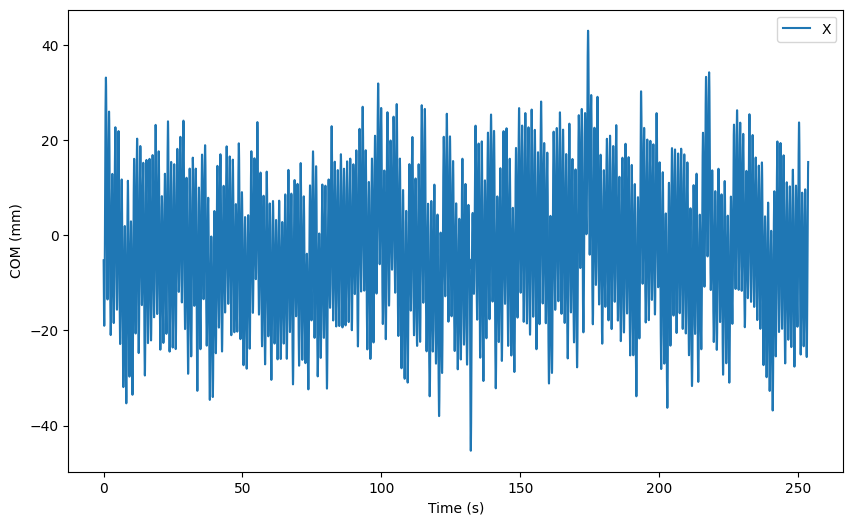

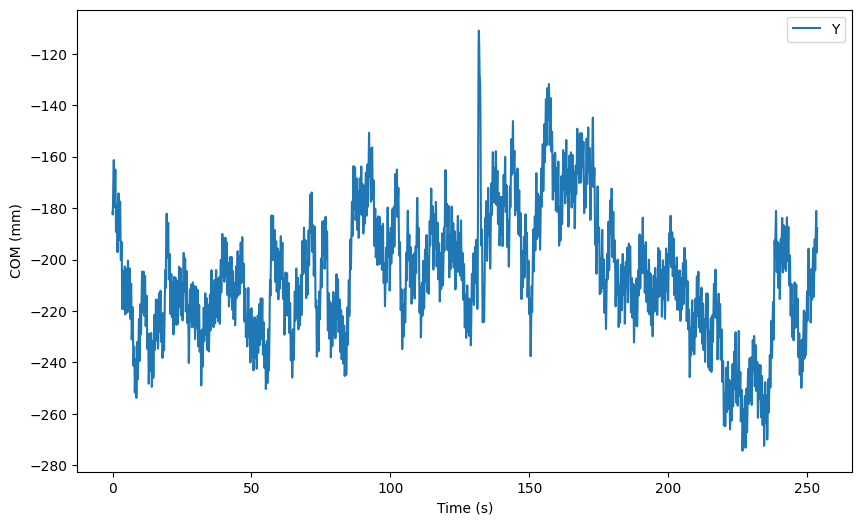

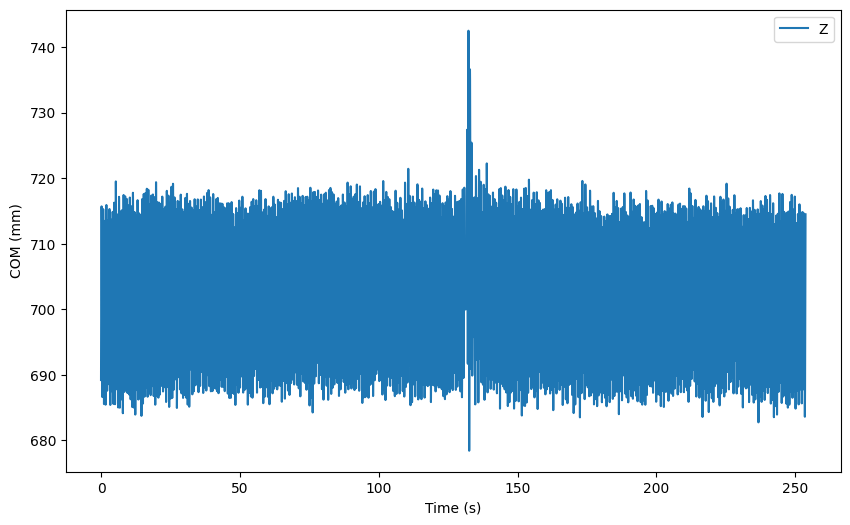

In [4]:
time = com.coords["time"].values      
x    = com.sel(axis="x").values       
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values


fig = plt.figure(figsize=(10, 6))     
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Time coordinates: 0.0 to 253.71
Selected COM shape: 20.02 119.31 (3, 9930)
Average stride duration: 1.1156179775280899 ± 0.014684322923779292 s


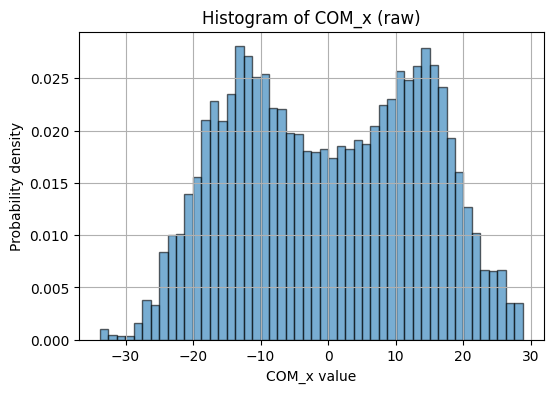

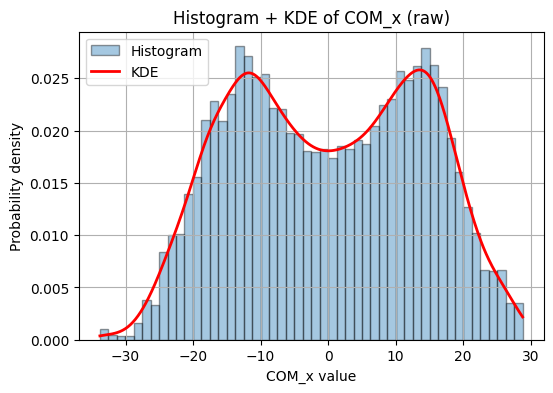


--- Axis: x ---


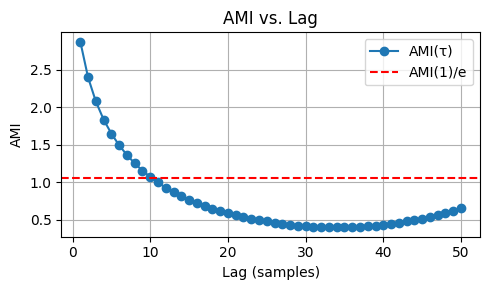

Optimal lag (τ) for axis x: 11 samples (0.110 s)


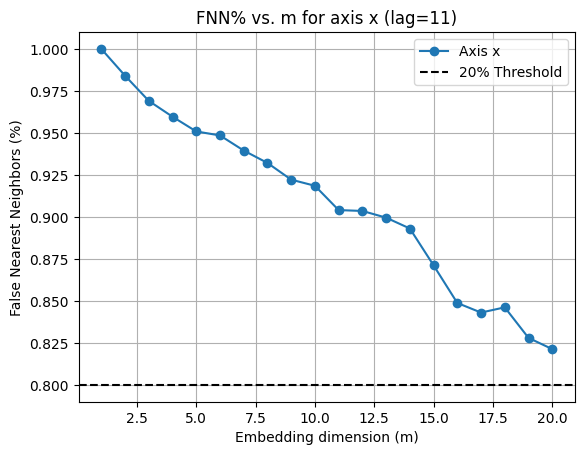

Optimal embedding dimension (m) for axis x: 18


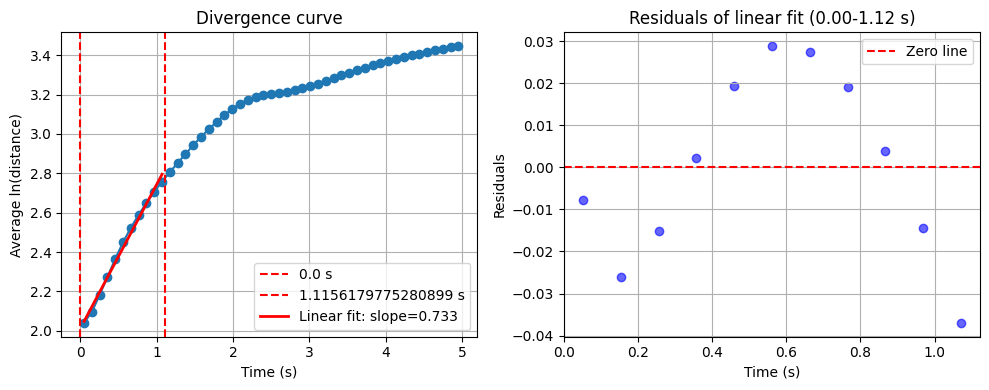

Lyapunov exponent (λ*) for axis x: 0.7325 1/s

--- Axis: z ---


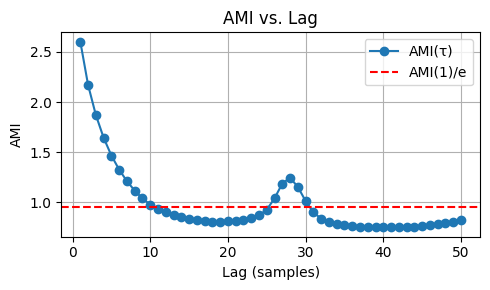

Optimal lag (τ) for axis z: 19 samples (0.190 s)


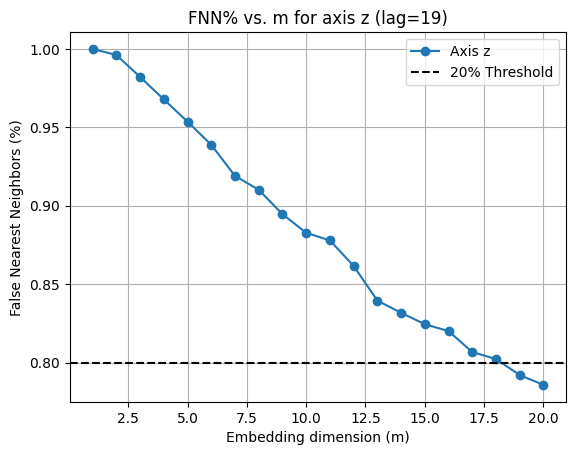

Optimal embedding dimension (m) for axis z: 13


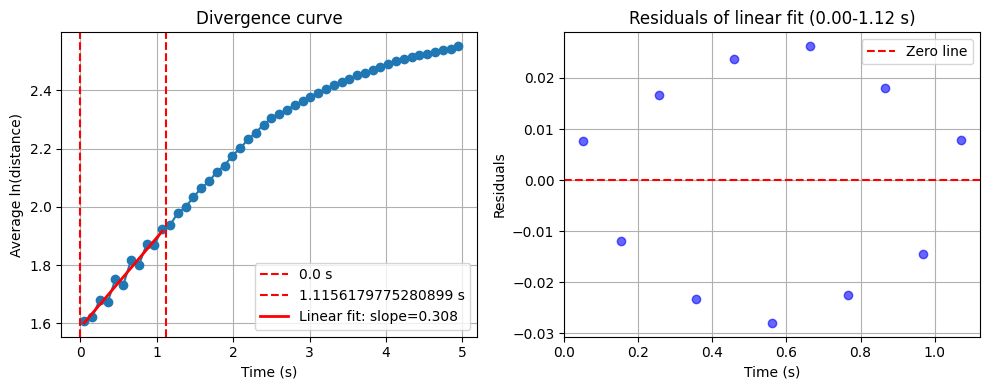

Lyapunov exponent (λ*) for axis z: 0.3082 1/s


In [11]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt

    import pandas as pd
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_16" /"Pre.3"/ "markers.nc"
    events_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_16" /"Pre.4"/ "Cereneo_SR_16_Fam_pre.4_events.csv"
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    fstrike_time = get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=120.0)
    start_time = fstrike_time['first_strike']
    end_time = fstrike_time['last_strike']
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)
    average_stride = get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=120.0)
    print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    # ts = com.sel(axis='x').values.ravel()
    # ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
    # for tau in [10, 20,40,50,100]:  # try a few small lags
    #     x1 = ts_raw[:-tau]   # x(t)
    #     x2 = ts_raw[tau:]    # x(t + tau)

    #     plt.figure(figsize=(5,5))
    #     plt.scatter(x1, x2, s=2, alpha=0.3)
    #     plt.xlabel(f'x(t)')
    #     plt.ylabel(f'x(t+{tau})')
    #     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    #     plt.grid(True)
    #     plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag, fs=fs,
            max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

## 17

In [ ]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_17" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")



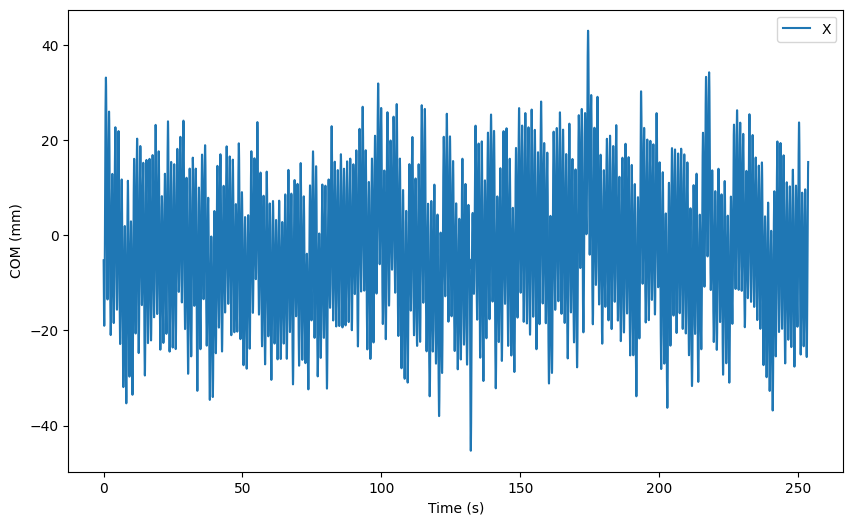

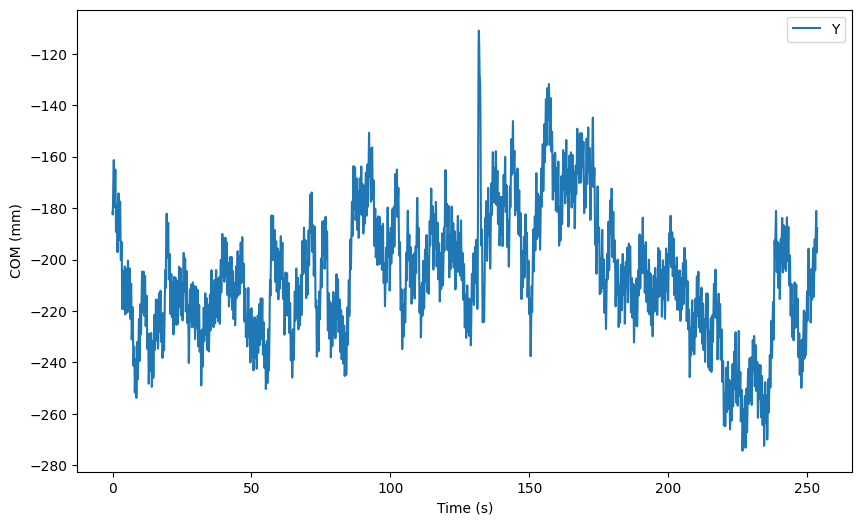

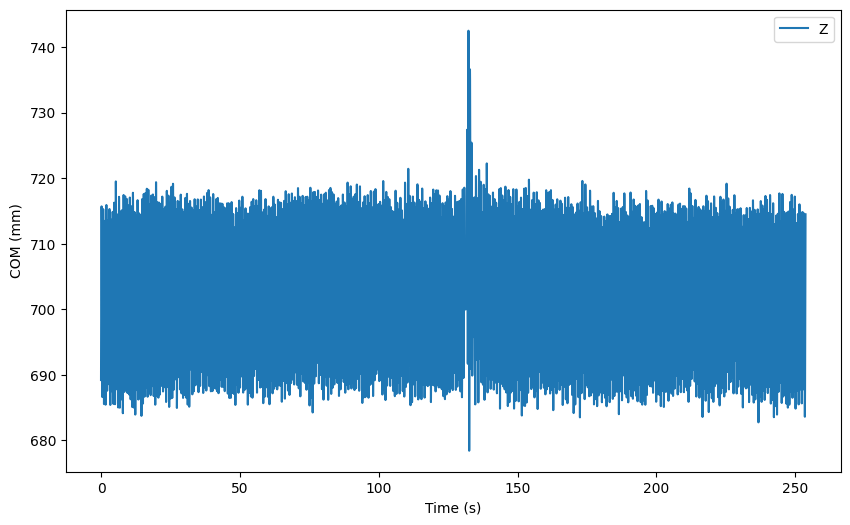

In [12]:
time = com.coords["time"].values      


x    = com.sel(axis="x").values  
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Time coordinates: 10.3 to 250.52
Selected COM shape: 20.88 119.59 (3, 9872)
Average stride duration: 1.1091011235955055 ± 0.016189915673777595 s


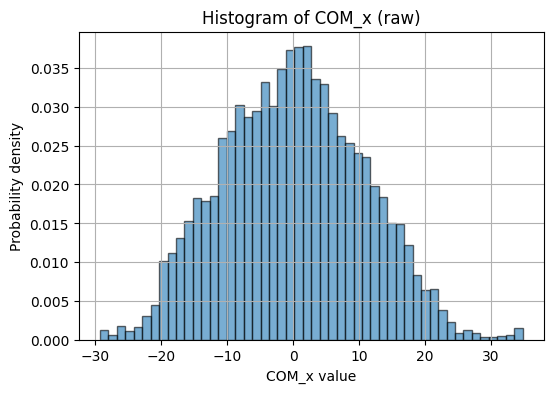

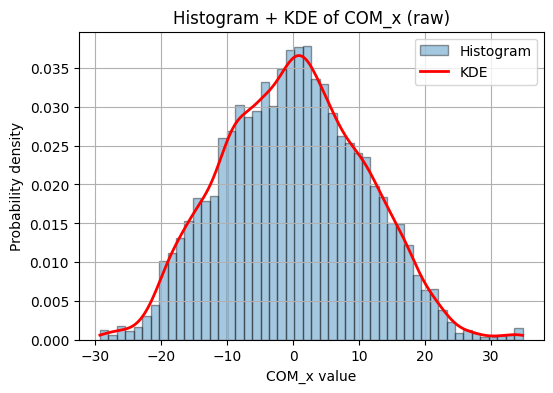


--- Axis: x ---


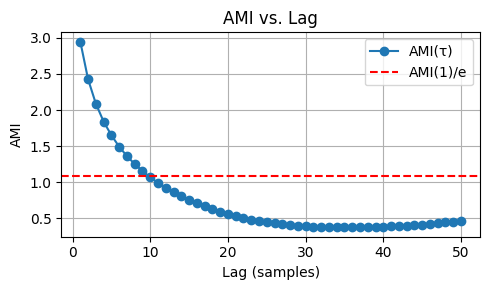

Optimal lag (τ) for axis x: 10 samples (0.100 s)


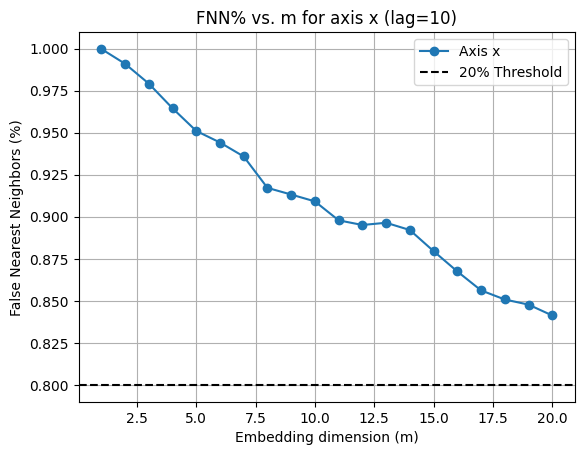

Optimal embedding dimension (m) for axis x: 8


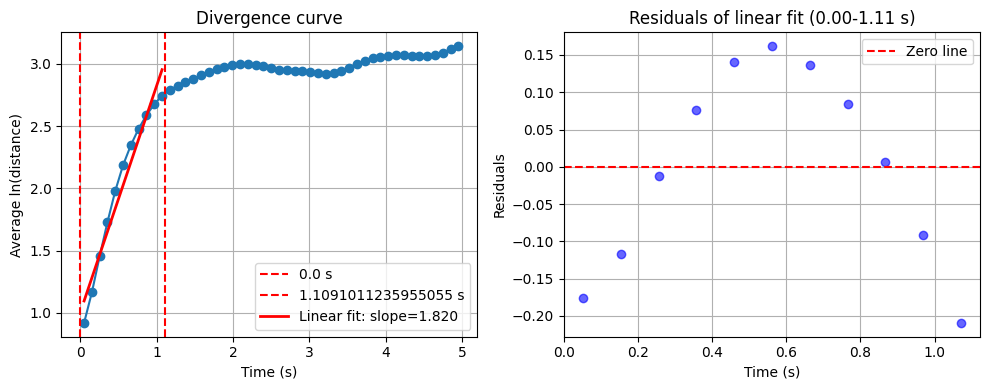

Lyapunov exponent (λ*) for axis x: 1.8200 1/s

--- Axis: z ---


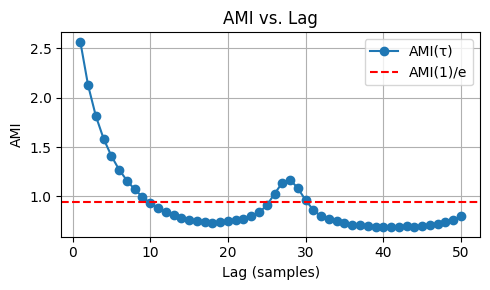

Optimal lag (τ) for axis z: 18 samples (0.180 s)


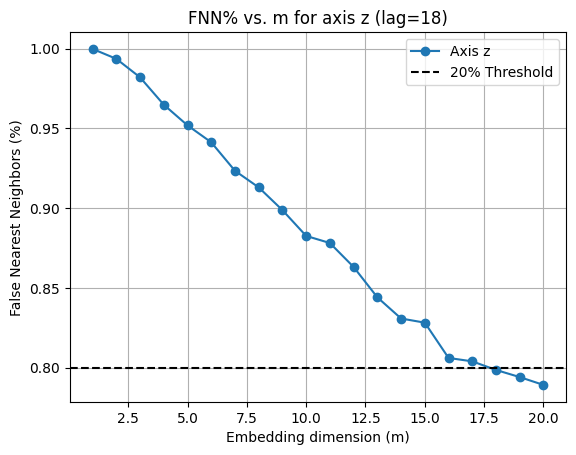

Optimal embedding dimension (m) for axis z: 16


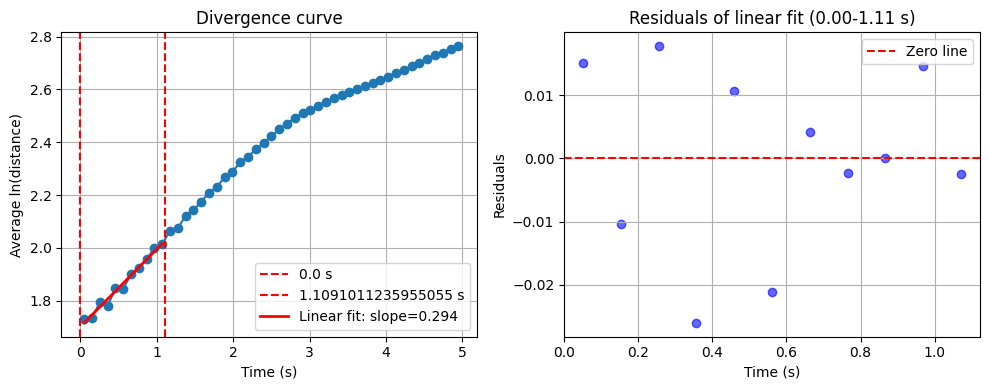

Lyapunov exponent (λ*) for axis z: 0.2939 1/s


In [14]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt

    import pandas as pd
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_17" /"Pre.3"/ "markers.nc"
    events_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_17" /"Pre.4"/ "events.nc"
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    fstrike_time = get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=120.0)
    start_time = fstrike_time['first_strike']
    end_time = fstrike_time['last_strike']
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)
    average_stride = get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=120.0)
    print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    # ts = com.sel(axis='x').values.ravel()
    # ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
    # for tau in [10, 20,40,50,100]:  # try a few small lags
    #     x1 = ts_raw[:-tau]   # x(t)
    #     x2 = ts_raw[tau:]    # x(t + tau)

    #     plt.figure(figsize=(5,5))
    #     plt.scatter(x1, x2, s=2, alpha=0.3)
    #     plt.xlabel(f'x(t)')
    #     plt.ylabel(f'x(t+{tau})')
    #     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    #     plt.grid(True)
    #     plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag, fs=fs,
            max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

## 18

In [15]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_18" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")



Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_18\Pre.3\markers.nc
File exists?:              True


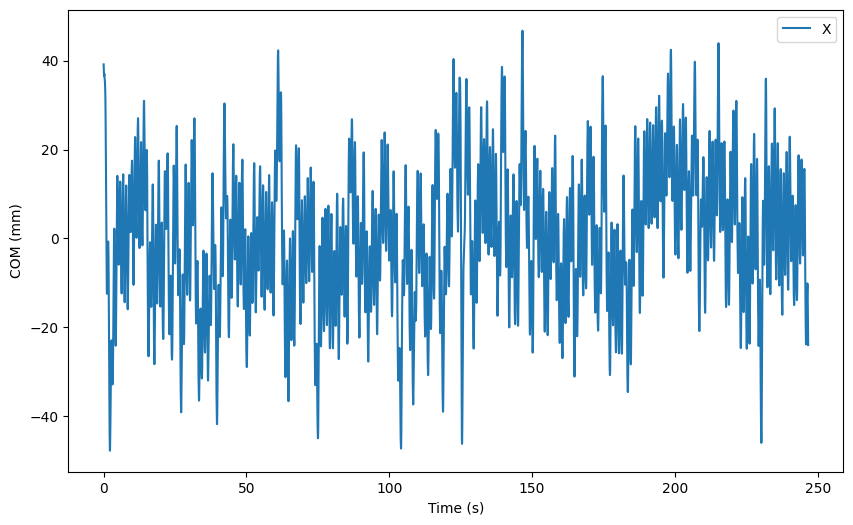

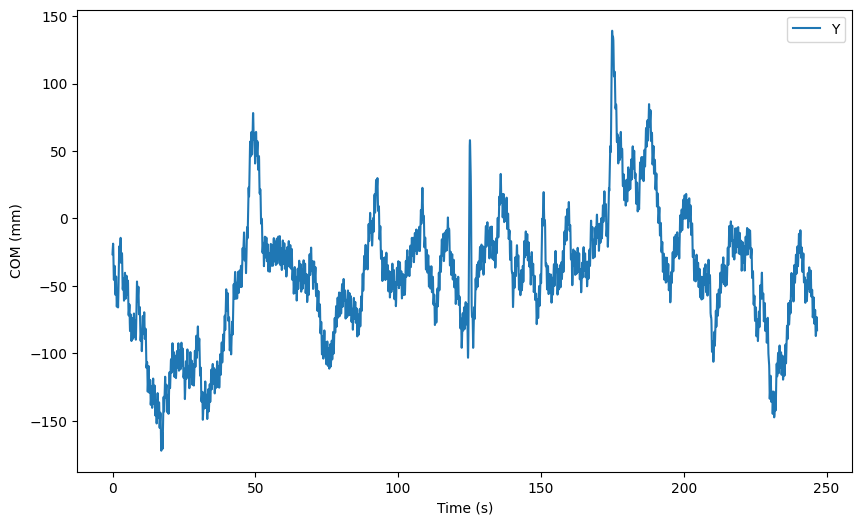

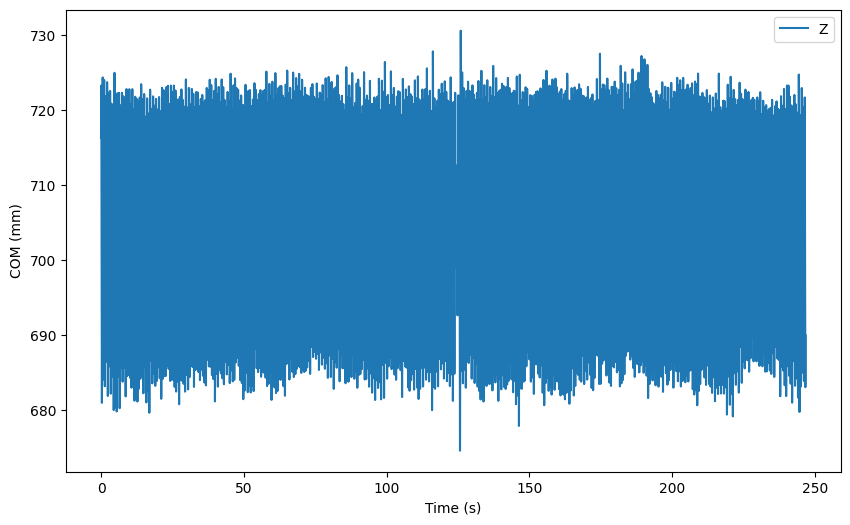

In [16]:
time = com.coords["time"].values      


x    = com.sel(axis="x").values  
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Time coordinates: 0.0 to 246.68
Selected COM shape: 20.52 119.52 (3, 9901)
Average stride duration: 1.0421052631578946 ± 0.011135031192933638 s


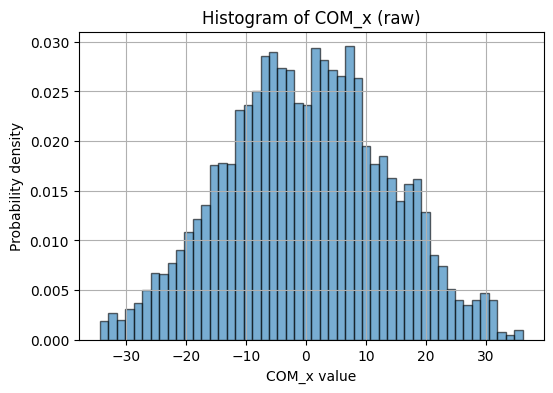

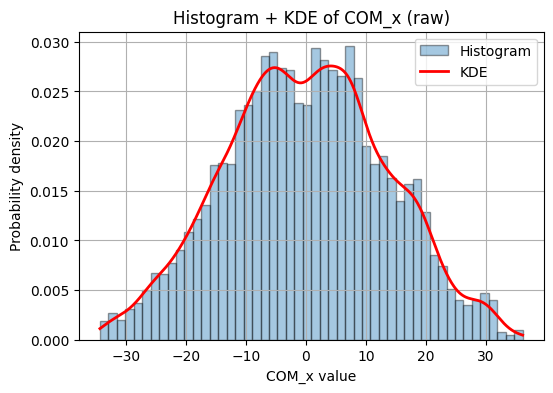


--- Axis: x ---


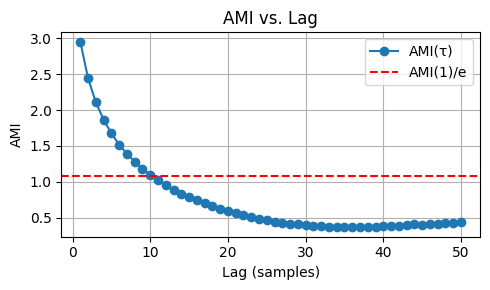

Optimal lag (τ) for axis x: 11 samples (0.110 s)


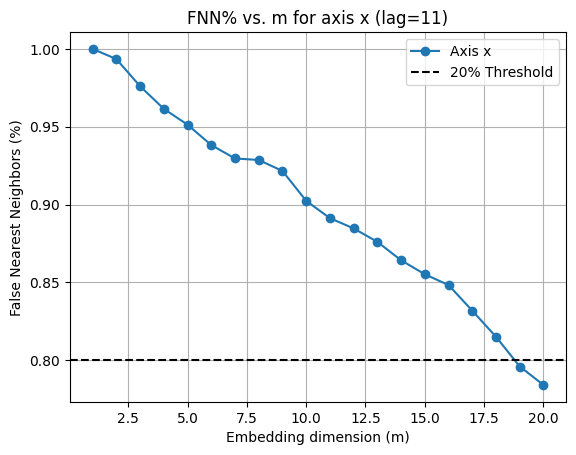

Optimal embedding dimension (m) for axis x: 9


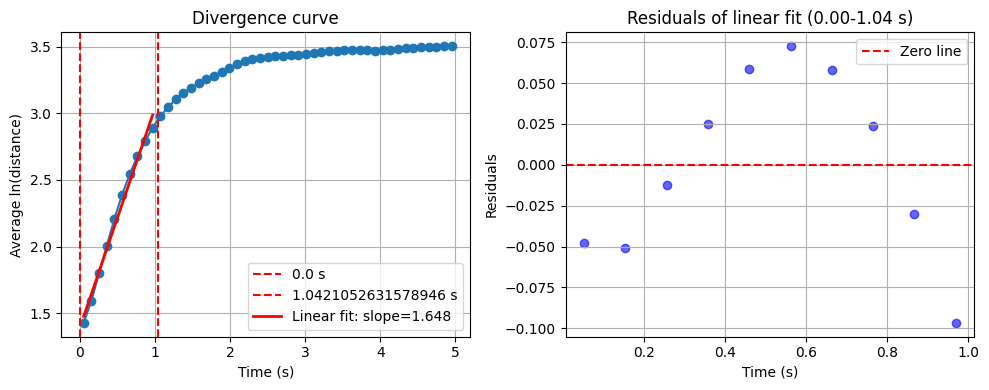

Lyapunov exponent (λ*) for axis x: 1.6478 1/s

--- Axis: z ---


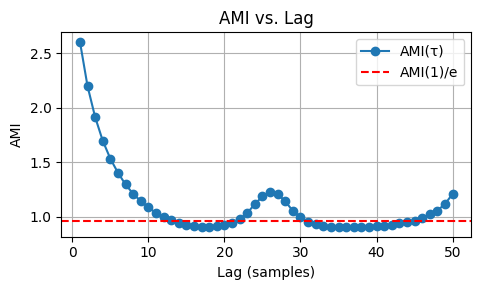

Optimal lag (τ) for axis z: 18 samples (0.180 s)


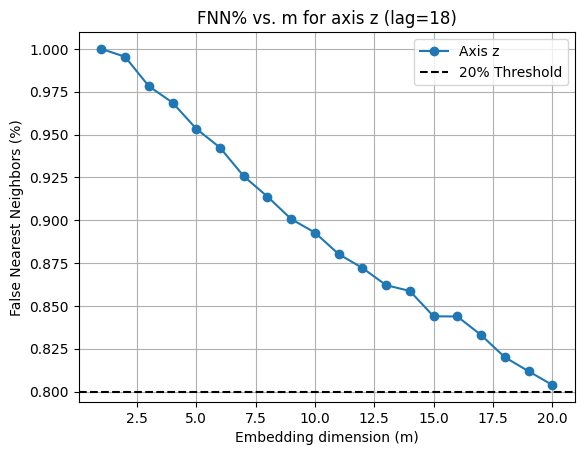

Optimal embedding dimension (m) for axis z: 15


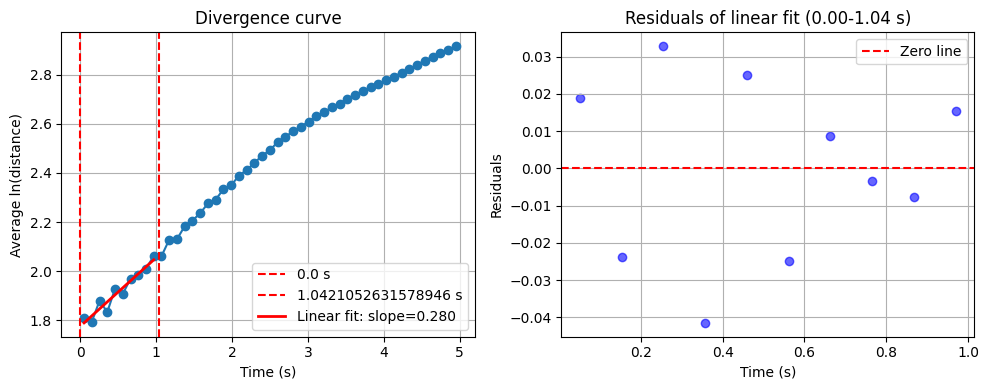

Lyapunov exponent (λ*) for axis z: 0.2796 1/s


In [17]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt

    import pandas as pd
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_18" /"Pre.3"/ "markers.nc"
    events_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_18" /"Pre.4"/ "events.nc"
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    fstrike_time = get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=120.0)
    start_time = fstrike_time['first_strike']
    end_time = fstrike_time['last_strike']
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)
    average_stride = get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=120.0)
    print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    # ts = com.sel(axis='x').values.ravel()
    # ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
    # for tau in [10, 20,40,50,100]:  # try a few small lags
    #     x1 = ts_raw[:-tau]   # x(t)
    #     x2 = ts_raw[tau:]    # x(t + tau)

    #     plt.figure(figsize=(5,5))
    #     plt.scatter(x1, x2, s=2, alpha=0.3)
    #     plt.xlabel(f'x(t)')
    #     plt.ylabel(f'x(t+{tau})')
    #     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    #     plt.grid(True)
    #     plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag, fs=fs,
            max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

## 19

In [18]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_19" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")



Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_19\Pre.3\markers.nc
File exists?:              True


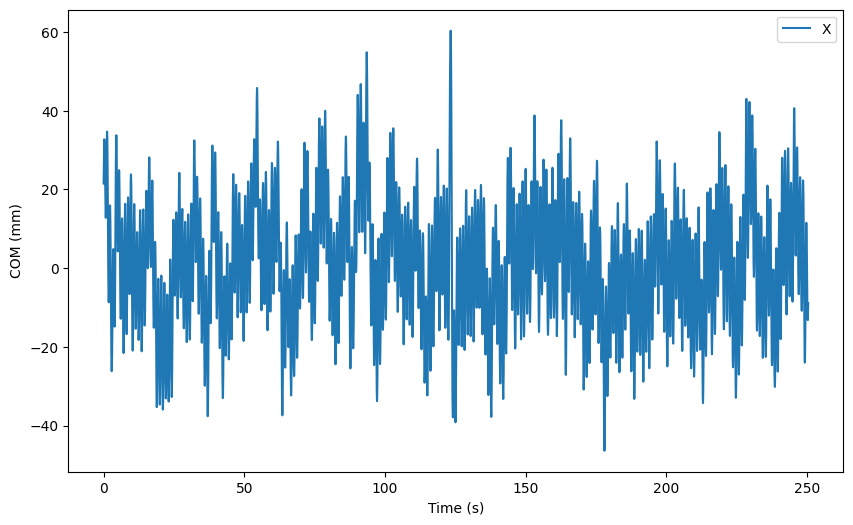

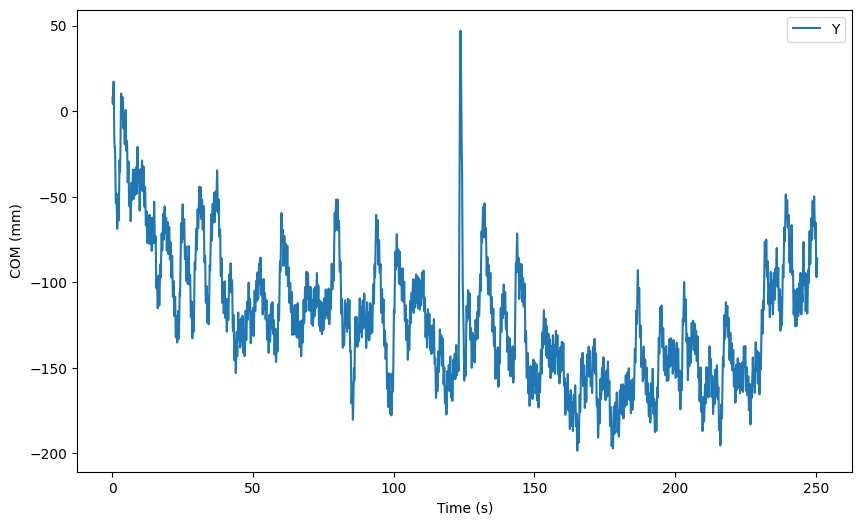

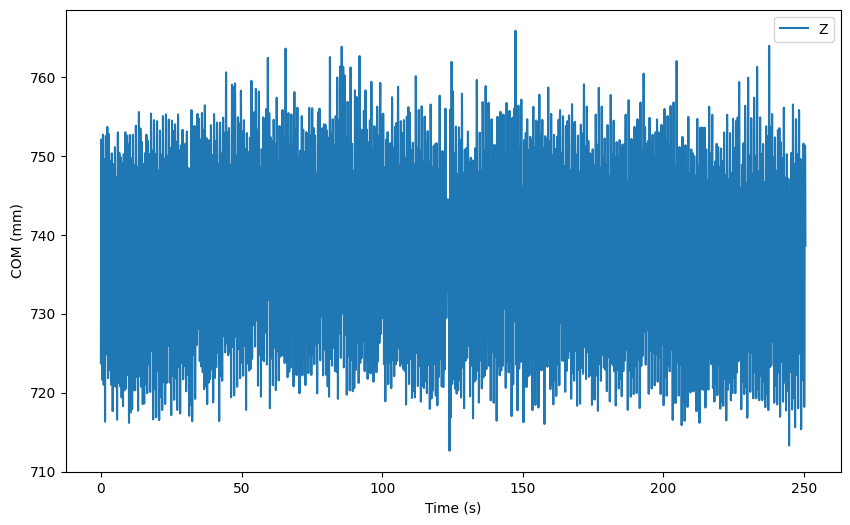

In [19]:
time = com.coords["time"].values      


x    = com.sel(axis="x").values  
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Time coordinates: 0.01 to 250.46
Selected COM shape: 20.69 119.02 (3, 9833)
Average stride duration: 1.0573118279569893 ± 0.011560014970618893 s


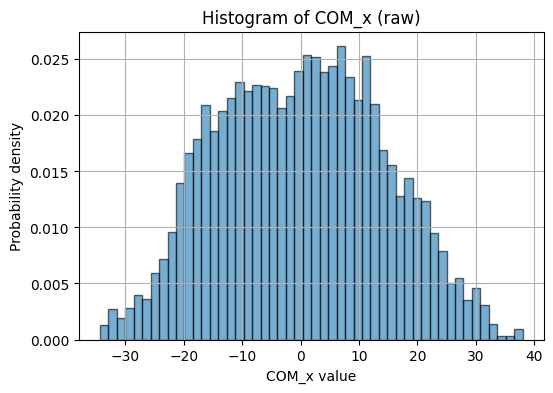

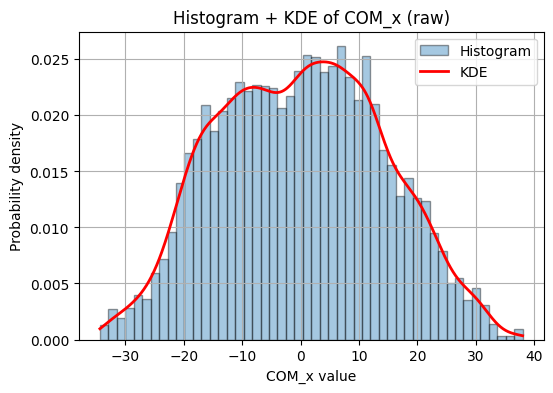


--- Axis: x ---


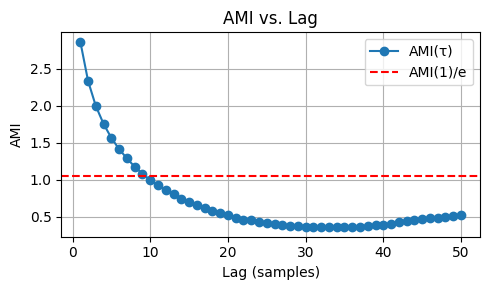

Optimal lag (τ) for axis x: 10 samples (0.100 s)


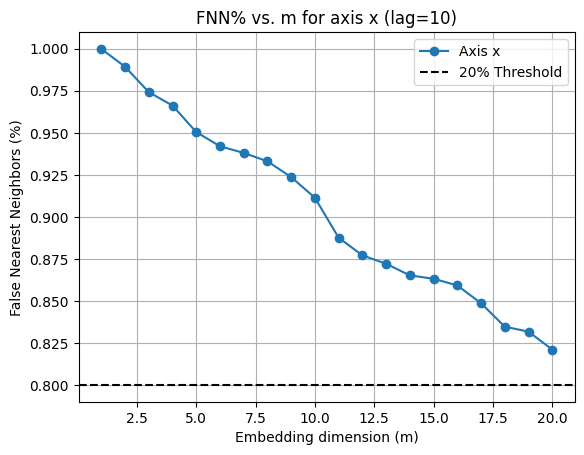

Optimal embedding dimension (m) for axis x: 11


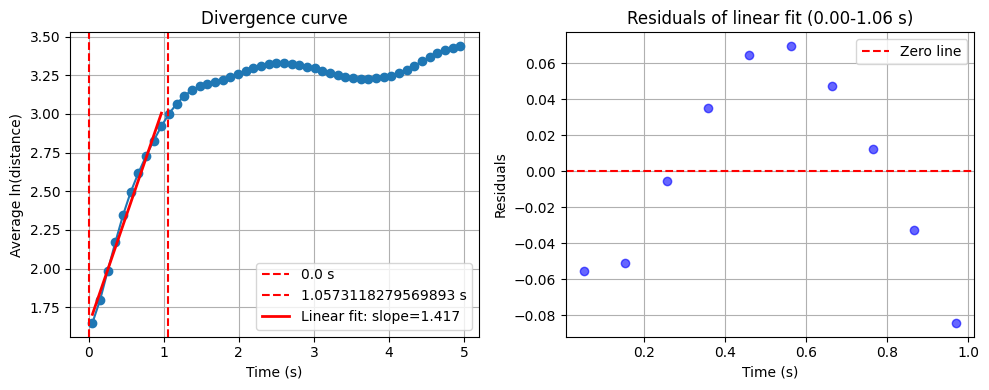

Lyapunov exponent (λ*) for axis x: 1.4175 1/s

--- Axis: z ---


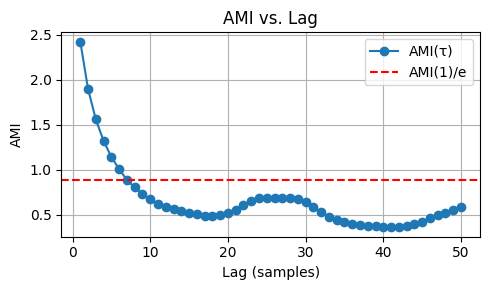

Optimal lag (τ) for axis z: 18 samples (0.180 s)


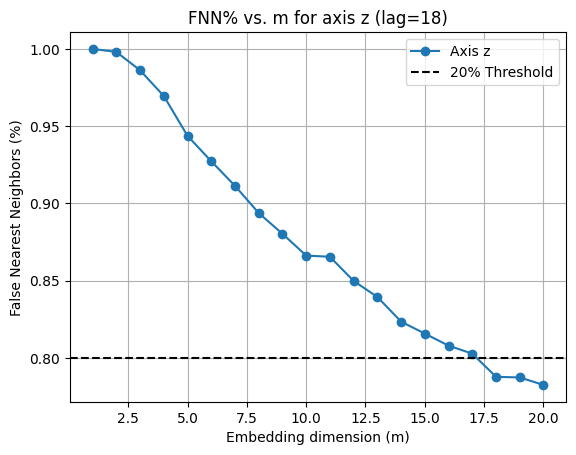

Optimal embedding dimension (m) for axis z: 11


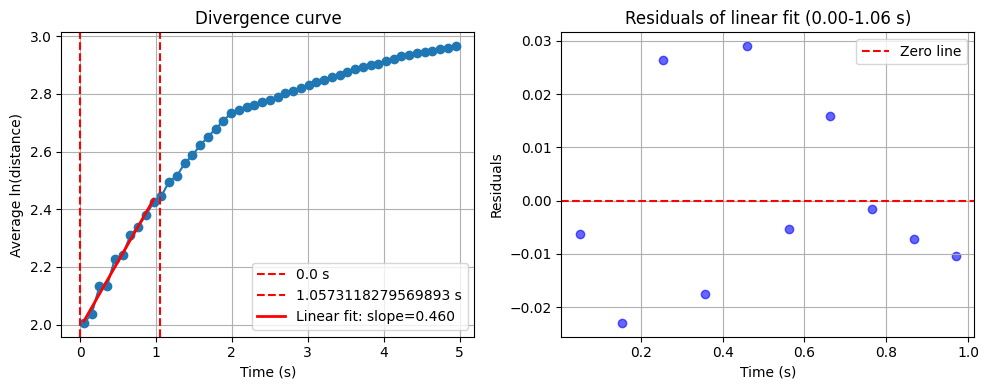

Lyapunov exponent (λ*) for axis z: 0.4598 1/s


In [20]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt

    import pandas as pd
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_19" /"Pre.3"/ "markers.nc"
    events_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_19" /"Pre.4"/ "events.nc"
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    fstrike_time = get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=120.0)
    start_time = fstrike_time['first_strike']
    end_time = fstrike_time['last_strike']
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)
    average_stride = get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=120.0)
    print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    # ts = com.sel(axis='x').values.ravel()
    # ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
    # for tau in [10, 20,40,50,100]:  # try a few small lags
    #     x1 = ts_raw[:-tau]   # x(t)
    #     x2 = ts_raw[tau:]    # x(t + tau)

    #     plt.figure(figsize=(5,5))
    #     plt.scatter(x1, x2, s=2, alpha=0.3)
    #     plt.xlabel(f'x(t)')
    #     plt.ylabel(f'x(t+{tau})')
    #     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    #     plt.grid(True)
    #     plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag, fs=fs,
            max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

## 20

In [21]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_20" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")



Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_20\Pre.3\markers.nc
File exists?:              True


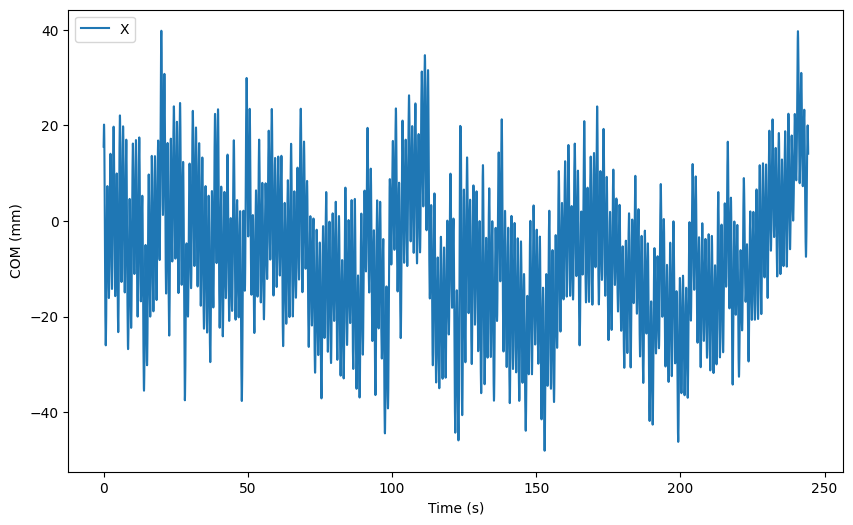

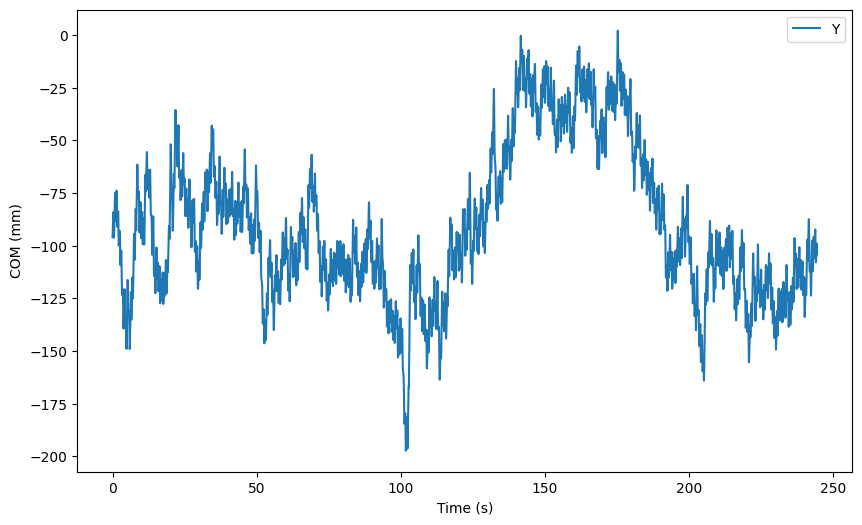

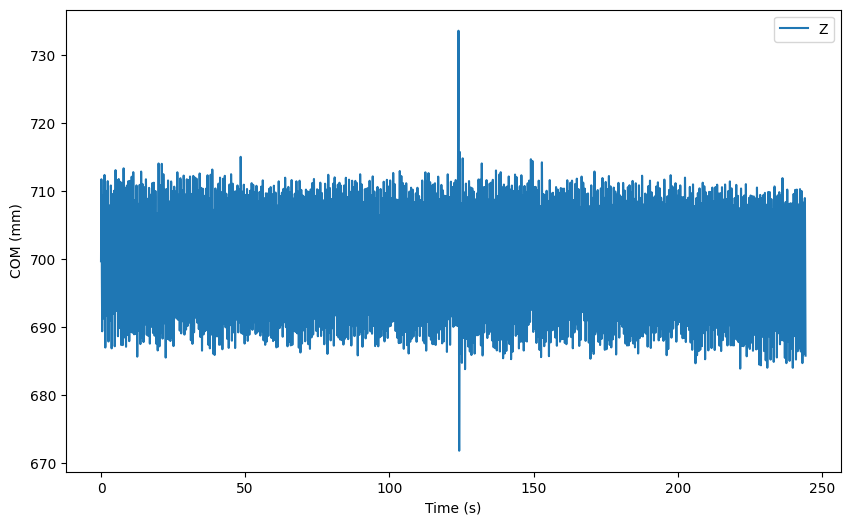

In [22]:
time = com.coords["time"].values      


x    = com.sel(axis="x").values  
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Time coordinates: 0.0 to 244.33
Selected COM shape: 20.18 119.35 (3, 9917)
Average stride duration: 1.101888888888889 ± 0.01692430497141382 s


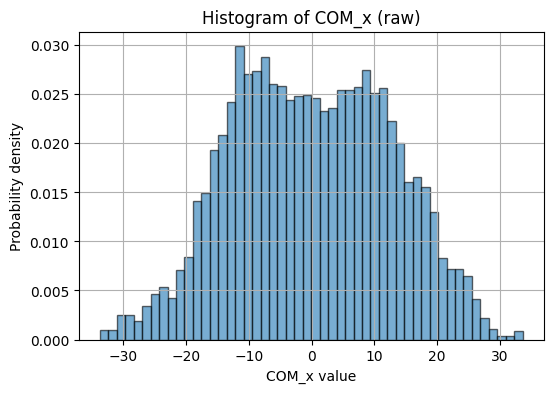

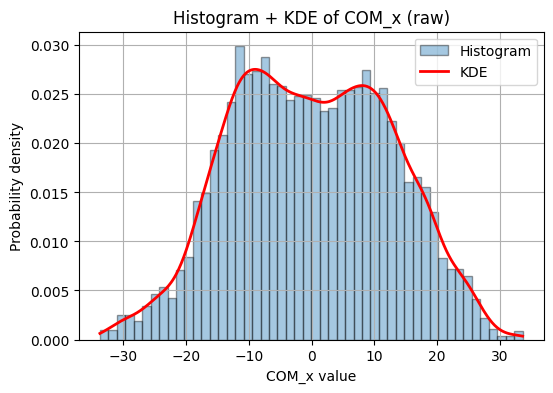


--- Axis: x ---


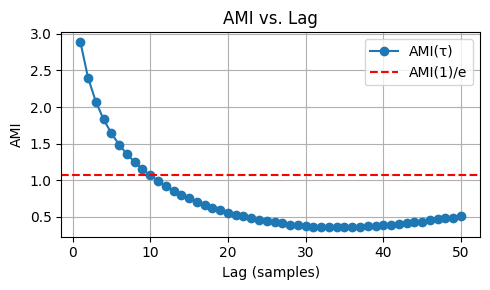

Optimal lag (τ) for axis x: 11 samples (0.110 s)


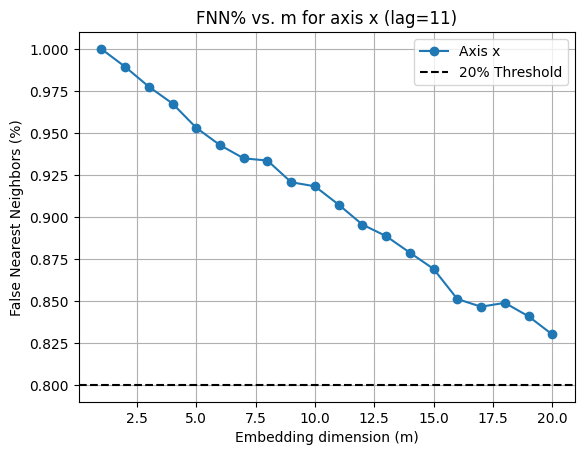

Optimal embedding dimension (m) for axis x: 16


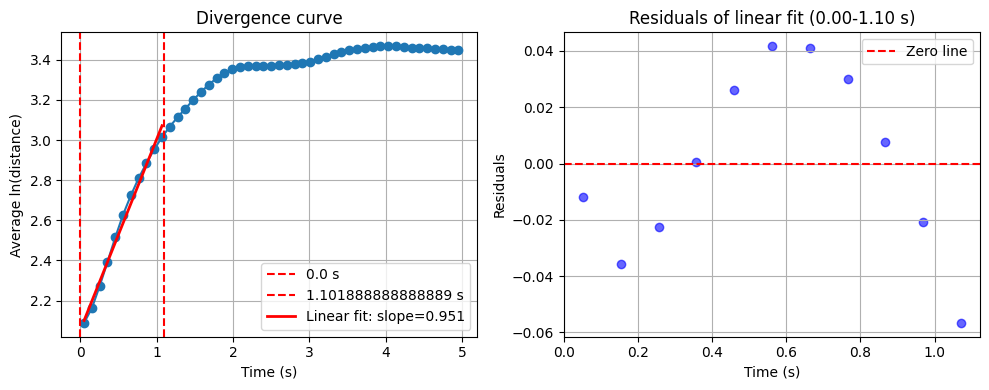

Lyapunov exponent (λ*) for axis x: 0.9513 1/s

--- Axis: z ---


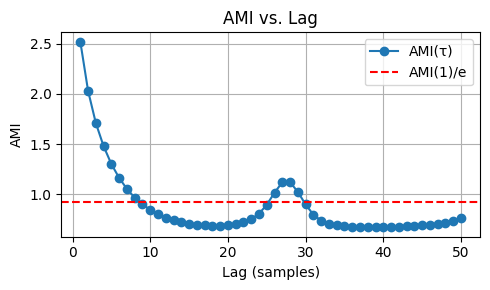

Optimal lag (τ) for axis z: 18 samples (0.180 s)


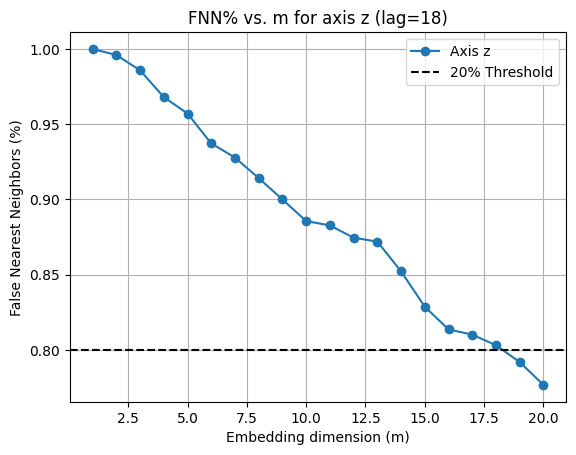

Optimal embedding dimension (m) for axis z: 13


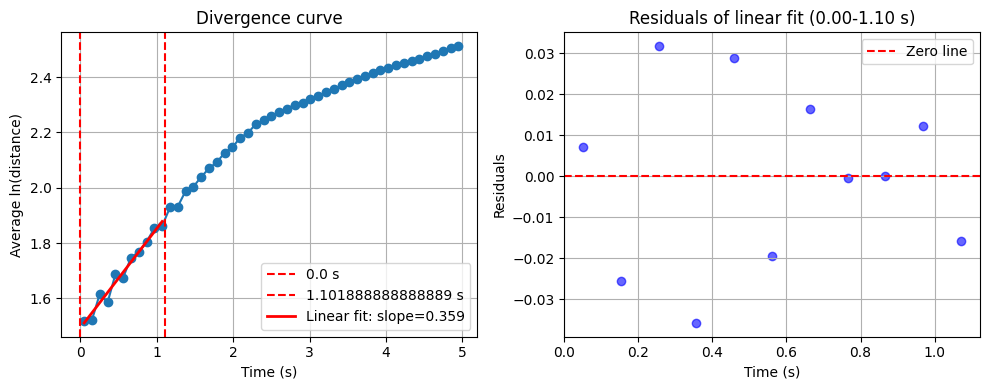

Lyapunov exponent (λ*) for axis z: 0.3594 1/s


In [23]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt

    import pandas as pd
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_20" /"Pre.3"/ "markers.nc"
    events_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_20" /"Pre.4"/ "events.nc"
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    fstrike_time = get_foot_strike(events_path, foot='Right', start_time=20.0, end_time=120.0)
    start_time = fstrike_time['first_strike']
    end_time = fstrike_time['last_strike']
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)
    average_stride = get_average_stride_duration(events_path, foot='Right', start_time=20.0, end_time=120.0)
    print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    # ts = com.sel(axis='x').values.ravel()
    # ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
    # for tau in [10, 20,40,50,100]:  # try a few small lags
    #     x1 = ts_raw[:-tau]   # x(t)
    #     x2 = ts_raw[tau:]    # x(t + tau)

    #     plt.figure(figsize=(5,5))
    #     plt.scatter(x1, x2, s=2, alpha=0.3)
    #     plt.xlabel(f'x(t)')
    #     plt.ylabel(f'x(t+{tau})')
    #     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    #     plt.grid(True)
    #     plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(
            ts, emb_dim=dim, lag=lag, fs=fs,
            max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()